In [1]:
# Install only packages missing from this notebook kernel.
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}
missing = [package for module, package in REQUIRED_PACKAGES.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are already installed.")

All required packages are already installed.


# RQ1 and RQ2: 108-run profile-construction analysis

This notebook analyzes the complete balanced experiment: three sites, four
models, three retrieval strategies, and three repetitions
($3\times4\times3\times3=108$). It reads normalized CSVs produced from the
saved profiles, current ground truth, frozen corpora, evidence reports, run
logs, and performance trackers. No live model, web, measurement, or pilot call
is made here.

**RQ1.** Can the pipeline construct accurate site profiles and abstain when the
site is silent?

**RQ2.** Does model or retrieval strategy affect profile quality, cost, and
run-to-run variation?

## Metrics and aggregation

- **Precision:** correct populated values divided by all populated values.
- **Recall:** correct populated values divided by all ground-truth fields that
  have a value.
- **Abstention accuracy:** correct abstentions divided by all ground-truth
  fields expected to be absent.
- **Field accuracy:** correct values plus correct abstentions divided by all
  evaluated fields.
- **Citation integrity:** accepted citations whose chunk exists, has
  target-site scope, matches the source URL, and contains the quoted text.
- **Tokens:** provider-reported input plus output tokens for profile extraction;
  the one-time frozen-corpus discovery cost is excluded.
- **Extraction latency:** time in documentation context selection, structured
  model calls, and evidence validation. The normalized CSV also retains total
  profile-build latency.
- **Run-to-run SD:** pooled within-configuration standard deviation across the
  three repetitions. This excludes differences among sites, models, and
  retrieval strategies from the repeatability statistic.

RQ1 site metrics aggregate field outcomes with equal weight for each
model-retrieval configuration. RQ2 quality and cost metrics macro-average the
balanced run matrix, so each site contributes equally.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Locate the repository when launched from its root or evaluation/notebooks.
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "evaluation").is_dir():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "evaluation").is_dir():
    raise FileNotFoundError("Run this notebook from inside the repository.")

EVALUATION = REPO_ROOT / "evaluation"
TABLE_DIR = EVALUATION / "analysis-108" / "tables"
FIGURE_DIR = EVALUATION / "analysis-108" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Edit these values to change paper figure dimensions and rendering.
WATERFALL_FIGSIZE = (3.45, 4.8)
PARETO_FIGSIZE = (3.45, 5.7)
PARETO_FOCUSED_YLIM = (0.80, 0.90)
PARETO_FULL_YLIM = (0.0, 1.0)
BAR_WIDTH = 0.22
DPI = 300

INK = "#2F3B45"
SITE_ORDER = ["anvil", "stampede3", "notre-dame-crc"]
SITE_LABELS = {
    "anvil": "Anvil",
    "stampede3": "Stampede3",
    "notre-dame-crc": "ND CRC",
}
SITE_COLORS = {
    "Anvil": "#4472C4",
    "Stampede3": "#2A9D8F",
    "ND CRC": "#E07A5F",
}
MODEL_ORDER = [
    "GPT-5 mini", "GPT-5.6 Terra", "Gemini 3.6 Flash", "Gemini 3.1 Pro"
]
MODEL_COLORS = {
    "GPT-5 mini": "#4472C4",
    "GPT-5.6 Terra": "#2A9D8F",
    "Gemini 3.6 Flash": "#E07A5F",
    "Gemini 3.1 Pro": "#8064A2",
}
MODEL_SHORT = {
    "GPT-5 mini": "Mini", "GPT-5.6 Terra": "Terra",
    "Gemini 3.6 Flash": "Flash", "Gemini 3.1 Pro": "Pro",
}
RETRIEVAL_ORDER = ["BM25", "LLM-expanded BM25", "Full corpus"]
RETRIEVAL_MARKERS = {
    "BM25": "o", "LLM-expanded BM25": "s", "Full corpus": "^"
}

sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.edgecolor": "#BEC7CE",
    "grid.color": "#DDE2E6",
    "text.color": INK,
    "axes.labelcolor": INK,
    "xtick.color": INK,
    "ytick.color": INK,
})

## Load and verify the experiment matrix

In [3]:
runs = pd.read_csv(TABLE_DIR / "normalized-runs.csv")
table_1 = pd.read_csv(TABLE_DIR / "table-1-results-by-site.csv")
table_3 = pd.read_csv(TABLE_DIR / "table-3-results-by-model.csv")
table_4 = pd.read_csv(TABLE_DIR / "table-4-results-by-retrieval.csv")
table_5 = pd.read_csv(TABLE_DIR / "table-5-model-retrieval-combinations.csv")
model_summary = pd.read_csv(TABLE_DIR / "model-summary-detailed.csv")
retrieval_summary = pd.read_csv(TABLE_DIR / "retrieval-summary-detailed.csv")
combination_summary = pd.read_csv(TABLE_DIR / "model-retrieval-summary-detailed.csv")
completion_runs = pd.read_csv(TABLE_DIR / "completion-by-run.csv")
diagnostics = pd.read_csv(TABLE_DIR / "model-retrieval-diagnostics.csv")

assert len(runs) == 108
assert runs.groupby(["site", "model", "mode"]).size().eq(3).all()
assert runs["corpus_fingerprint"].nunique() == 3
matrix_check = runs.groupby(["site", "model", "mode"]).size().rename("repetitions")
print(f"Validated {len(runs)} runs; {len(matrix_check)} configurations; "
      f"{matrix_check.min()} repetitions per configuration.")
display(runs.groupby(["site", "model", "mode"]).size().unstack("mode"))

Validated 108 runs; 36 configurations; 3 repetitions per configuration.


mode                                   bm25  expanded  full-corpus
site           model                                              
anvil          gemini-3.1-pro-preview     3         3            3
               gemini-3.6-flash           3         3            3
               gpt-5-mini                 3         3            3
               gpt-5.6-terra              3         3            3
notre-dame-crc gemini-3.1-pro-preview     3         3            3
               gemini-3.6-flash           3         3            3
               gpt-5-mini                 3         3            3
               gpt-5.6-terra              3         3            3
stampede3      gemini-3.1-pro-preview     3         3            3
               gemini-3.6-flash           3         3            3
               gpt-5-mini                 3         3            3
               gpt-5.6-terra              3         3            3

## IEEE LaTeX table helper

In [4]:
def ieee_latex_table(
    frame,
    *,
    caption,
    label,
    column_format=None,
    float_format="%.3f",
    font_size="footnotesize",
):
    """Return a compact booktabs table for an IEEE paper."""
    if column_format is None:
        column_format = "l" + "r" * (len(frame.columns) - 1)
    tabular = frame.to_latex(
        index=False,
        escape=True,
        column_format=column_format,
        float_format=float_format,
    ).strip()
    return "\n".join([
        r"\begin{table}[t]",
        f"\\caption{{{caption}}}",
        f"\\label{{{label}}}",
        r"\centering",
        f"\\{font_size}",
        r"\setlength{\tabcolsep}{4pt}",
        tabular,
        r"\end{table}",
    ])

## Table 1: RQ1 results by site

The table reports final profile quality after deterministic evidence validation
and reconciliation. Citation integrity is a mechanical provenance check, not a
semantic judgment of whether a cited sentence proves the extracted value.

In [5]:
table_1_display = table_1.copy()
for column in table_1_display.columns[1:]:
    table_1_display[column] = table_1_display[column].map(lambda value: f"{value:.3f}")
display(table_1_display)

# print(ieee_latex_table(
#     table_1,
#     caption="Profile-construction quality by site over 36 runs per site.",
#     label="tab:rq1-site-results",
# ))

,Site,Precision,Recall,Abstention Accuracy,Field Accuracy,Citation Integrity
0,Anvil,0.979,0.874,0.969,0.895,1.000
1,Stampede3,0.957,0.904,0.934,0.910,1.000
2,Notre Dame CRC,0.992,0.771,0.986,0.783,1.000


## Table 3: RQ2 results by model

In [6]:
table_3_display = table_3.copy()
display(table_3_display.style.format({
    "Field Accuracy": "{:.3f}", "Precision": "{:.3f}", "Recall": "{:.3f}",
    "Tokens": "{:,.0f}", "Latency": "{:.1f}", "Run-to-Run SD": "{:.3f}",
}))

# print(ieee_latex_table(
#     table_3_display,
#     caption="Profile quality and extraction cost by model (27 runs per model).",
#     label="tab:rq2-model-results",
# ))

,Model,Field Accuracy,Precision,Recall,Tokens,Latency,Run-to-Run SD
0,GPT-5 mini,0.841,0.959,0.826,"89,513",362.0,0.040
1,GPT-5.6 Terra,0.866,0.982,0.851,"58,368",51.9,0.012
2,Gemini 3.6 Flash,0.875,0.980,0.864,"87,109",150.2,0.013
3,Gemini 3.1 Pro,0.869,0.980,0.857,"86,481",221.3,0.014


## Table 4: RQ2 results by retrieval strategy

In [7]:
table_4_display = table_4.copy()
display(table_4_display.style.format({
    "Field Accuracy": "{:.3f}", "Precision": "{:.3f}", "Recall": "{:.3f}",
    "Tokens": "{:,.0f}", "Latency": "{:.1f}", "Run-to-Run SD": "{:.3f}",
}))

# print(ieee_latex_table(
#     table_4_display,
#     caption="Profile quality and extraction cost by retrieval strategy (36 runs each).",
#     label="tab:rq2-retrieval-results",
# ))

,Retrieval,Field Accuracy,Precision,Recall,Tokens,Latency,Run-to-Run SD
0,BM25,0.868,0.976,0.855,"57,590",129.9,0.021
1,LLM-expanded BM25,0.859,0.975,0.847,"57,678",143.2,0.028
2,Full corpus,0.861,0.976,0.847,"125,835",315.9,0.017


## Table 5: Model-retrieval combinations

In [8]:
table_5_display = table_5.copy()
display(table_5_display.style.format({
    "Field Accuracy": "{:.3f}", "Tokens": "{:,.0f}",
    "Latency": "{:.1f}", "Run-to-Run SD": "{:.3f}",
}))

# print(ieee_latex_table(
#     table_5_display,
#     caption="Quality-cost results for each model-retrieval combination (nine runs each).",
#     label="tab:rq2-combinations",
#     font_size="scriptsize",
# ))

,Model,Retrieval,Field Accuracy,Tokens,Latency,Run-to-Run SD
0,GPT-5 mini,BM25,0.823,"62,696",244.0,0.041
1,GPT-5 mini,LLM-expanded BM25,0.843,"67,742",282.7,0.044
2,GPT-5 mini,Full corpus,0.858,"138,100",559.2,0.033
3,GPT-5.6 Terra,BM25,0.882,"40,943",36.5,0.002
4,GPT-5.6 Terra,LLM-expanded BM25,0.857,"40,027",39.4,0.021
5,GPT-5.6 Terra,Full corpus,0.860,"94,133",79.7,0.000
6,Gemini 3.6 Flash,BM25,0.886,"61,069",89.9,0.003
7,Gemini 3.6 Flash,LLM-expanded BM25,0.873,"59,458",100.0,0.020
8,Gemini 3.6 Flash,Full corpus,0.867,"140,801",260.6,0.011
9,Gemini 3.1 Pro,BM25,0.882,"65,653",149.2,0.013


## RQ1 profile-completion waterfall

Each floating bar is the incremental fraction of evaluated fields completed by
one evidence path. The final bar is the total fraction completed correctly;
the unfilled space is incorrect or unresolved. The first version shows the
mean cumulative contribution, with $\pm1$ standard deviation over the 36 runs
at each site shown on the cumulative line.

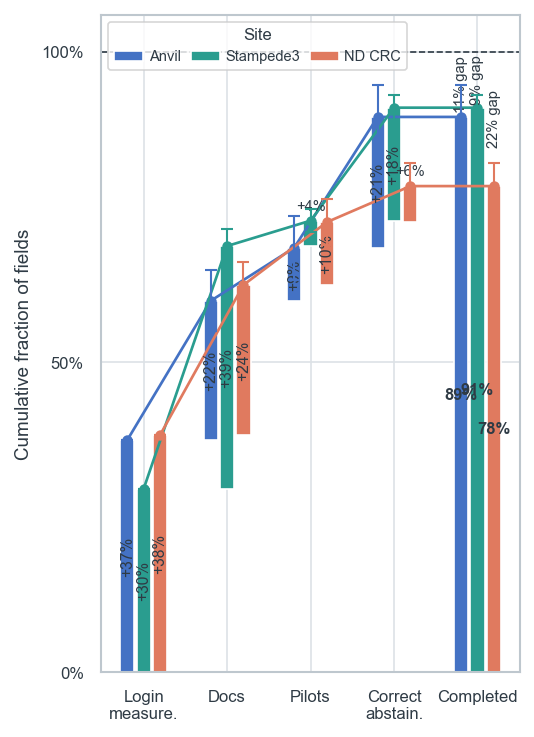

In [9]:
COMPLETION_ORDER = [
    "measured_correctly", "recovered_documentation", "recovered_pilot",
    "correct_abstention", "error_or_unresolved",
]
CONTRIBUTIONS = COMPLETION_ORDER[:-1]
STAGE_LABELS = [
    "Login\nmeasure.", "Docs", "Pilots", "Correct\nabstain.", "Completed",
]


def completion_pivot():
    # Return one row per run with all completion fractions present.
    pivot = completion_runs.pivot_table(
        index=["run_id", "site"], columns="completion_segment",
        values="fraction", fill_value=0,
    ).reset_index()
    for column in COMPLETION_ORDER:
        if column not in pivot:
            pivot[column] = 0.0
    return pivot


def draw_completion_waterfall(axis, *, error_bars=True):
    # Draw all three sites in one single-column grouped waterfall.
    pivot = completion_pivot()
    x = np.arange(len(STAGE_LABELS), dtype=float) * 1.12
    bar_width = 0.19
    offsets = np.linspace(-0.22, 0.22, len(SITE_ORDER))
    for site_index, site in enumerate(SITE_ORDER):
        site_runs = pivot[pivot["site"] == site]
        increments = site_runs[CONTRIBUTIONS].mean().to_numpy(float)
        before = np.concatenate(([0.0], np.cumsum(increments)[:-1]))
        after = np.cumsum(increments)
        completed = after[-1]
        gap = site_runs["error_or_unresolved"].mean()
        label = SITE_LABELS[site]
        color = SITE_COLORS[label]

        for stage_index, (height, bottom) in enumerate(zip(increments, before)):
            position = x[stage_index] + offsets[site_index]
            axis.bar(
                position, height, width=bar_width, bottom=bottom, color=color,
                label=label if stage_index == 0 else None,
            )
            if height >= 0.065:
                axis.text(
                    position, bottom + height / 2, f"+{height:.0%}",
                    ha="center", va="center", fontsize=7.5, rotation=90,
                )
            else:
                axis.text(
                    position, bottom + height + 0.012, f"+{height:.0%}",
                    ha="center", va="bottom", fontsize=7,
                )

        final_position = x[-1] + offsets[site_index]
        axis.bar(
            final_position, completed, width=bar_width, color=color,
        )
        axis.text(
            final_position, completed / 2, f"{completed:.0%}",
            ha="center", va="center", fontsize=8, fontweight="bold",
        )
        if gap >= 0.035:
            axis.text(
                final_position, completed + gap / 2, f"{gap:.0%} gap",
                ha="center", va="center", fontsize=7, rotation=90,
            )

        cumulative_by_run = site_runs[CONTRIBUTIONS].cumsum(axis=1)
        cumulative_mean = cumulative_by_run.mean().to_numpy(float)
        cumulative_sd = cumulative_by_run.std(ddof=1).to_numpy(float)
        tops = np.append(cumulative_mean, cumulative_mean[-1])
        axis.plot(
            x + offsets[site_index], tops, marker="o", linewidth=1.3,
            markersize=4, color=color,
        )
        if error_bars:
            errors = np.append(cumulative_sd, cumulative_sd[-1])
            axis.errorbar(
                x + offsets[site_index], tops, yerr=errors, fmt="none",
                ecolor=color, elinewidth=1.0, capsize=3.0, zorder=4,
            )

    axis.axhline(1, color=INK, linewidth=0.8, linestyle="--")
    axis.set_ylim(0, 1.06)
    axis.set_xticks(x, STAGE_LABELS)
    axis.set_yticks([0, 0.5, 1], ["0%", "50%", "100%"])
    axis.set_ylabel("Cumulative fraction of fields", fontsize=9)
    axis.tick_params(axis="both", labelsize=8)
    axis.legend(
        title="Site", ncol=3, loc="upper left", fontsize=7,
        title_fontsize=8, columnspacing=0.7, handletextpad=0.35,
    )
    return axis


waterfall, axis = plt.subplots(figsize=WATERFALL_FIGSIZE, constrained_layout=True)
draw_completion_waterfall(axis, error_bars=True)
waterfall.savefig(FIGURE_DIR / "profile-completion-waterfall-error-bars.pdf")
# waterfall.savefig(
#     FIGURE_DIR / "profile-completion-waterfall-error-bars.png", dpi=DPI
# )
plt.show()

In [10]:
# For a mean-only version, call draw_completion_waterfall(axis, error_bars=False).

## RQ2 quality-cost Pareto figure

Each point averages nine runs: three sites and three repetitions. Color denotes
model and marker shape denotes retrieval strategy. A point is on the observed
Pareto frontier when no other observed configuration is both cheaper and at
least as accurate. The primary view truncates the field-accuracy axis to expose
small differences among configurations; the following cell also renders a
full 0–1 scale.

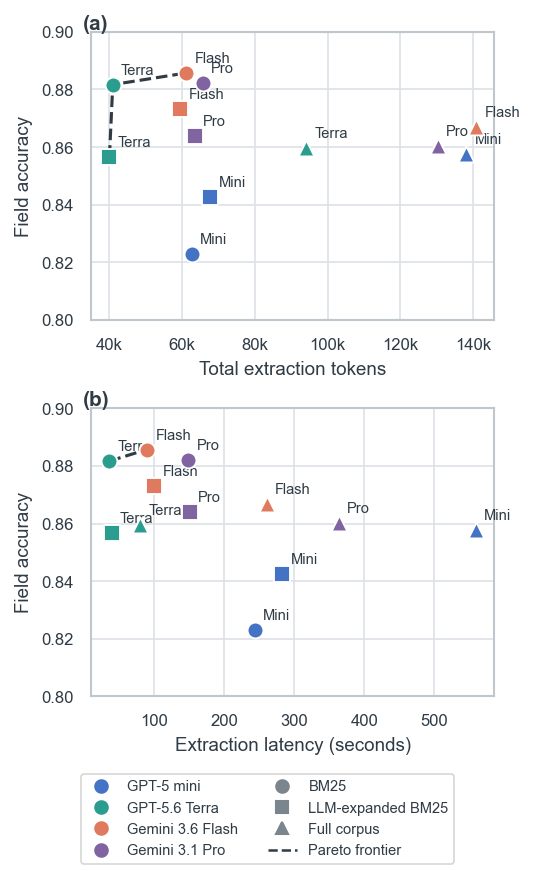

In [11]:
def pareto_frontier(frame, cost_column):
    # Return observed points not dominated on lower cost and higher quality.
    ordered = frame.sort_values([cost_column, "field_accuracy"], ascending=[True, False])
    best_accuracy = -np.inf
    rows = []
    for _, row in ordered.iterrows():
        if row["field_accuracy"] > best_accuracy:
            rows.append(row)
            best_accuracy = row["field_accuracy"]
    return pd.DataFrame(rows)


def plot_quality_cost(*, ylim=PARETO_FOCUSED_YLIM):
    # Plot field accuracy versus tokens and extraction latency.
    frame = combination_summary.copy()
    figure, axes = plt.subplots(2, 1, figsize=PARETO_FIGSIZE, constrained_layout=True)
    panels = [
        ("a", "tokens", "Total extraction tokens", axes[0]),
        ("b", "latency_sec", "Extraction latency (seconds)", axes[1]),
    ]
    for panel, cost, xlabel, axis in panels:
        for _, row in frame.iterrows():
            axis.scatter(
                row[cost], row["field_accuracy"],
                s=58,
                color=MODEL_COLORS[row["Model"]],
                marker=RETRIEVAL_MARKERS[row["Retrieval"]],
                edgecolor="white", linewidth=0.9, zorder=3,
            )
            axis.annotate(
                MODEL_SHORT[row["Model"]],
                (row[cost], row["field_accuracy"]),
                xytext=(4, 5), textcoords="offset points", fontsize=7,
            )
        frontier = pareto_frontier(frame, cost)
        axis.plot(
            frontier[cost], frontier["field_accuracy"],
            color=INK, linestyle="--", linewidth=1.5, zorder=2,
        )
        axis.set_xlabel(xlabel, fontsize=9)
        axis.set_ylabel("Field accuracy", fontsize=9)
        axis.tick_params(axis="both", labelsize=8)
        axis.set_ylim(*ylim)
        axis.text(
            -0.02, 1.06, f"({panel})", transform=axis.transAxes,
            fontsize=10, fontweight="bold", va="top",
        )
    axes[0].xaxis.set_major_formatter(
        FuncFormatter(lambda value, _: f"{value / 1000:.0f}k")
    )
    handles = [
        *[
            Line2D([0], [0], marker="o", linestyle="none", color=color,
                   label=model, markersize=6)
            for model, color in MODEL_COLORS.items()
        ],
        *[
            Line2D([0], [0], marker=marker, linestyle="none", color="#7B858D",
                   label=retrieval, markersize=6)
            for retrieval, marker in RETRIEVAL_MARKERS.items()
        ],
        Line2D([0], [0], color=INK, linestyle="--", label="Pareto frontier"),
    ]
    figure.legend(
        handles=handles, ncol=2, loc="outside lower center", fontsize=7,
    )
    return figure, axes


pareto_focused, _ = plot_quality_cost(ylim=PARETO_FOCUSED_YLIM)
pareto_focused.savefig(FIGURE_DIR / "rq2-quality-cost-pareto.pdf")
# pareto_focused.savefig(FIGURE_DIR / "rq2-quality-cost-pareto.png", dpi=DPI)
plt.show()

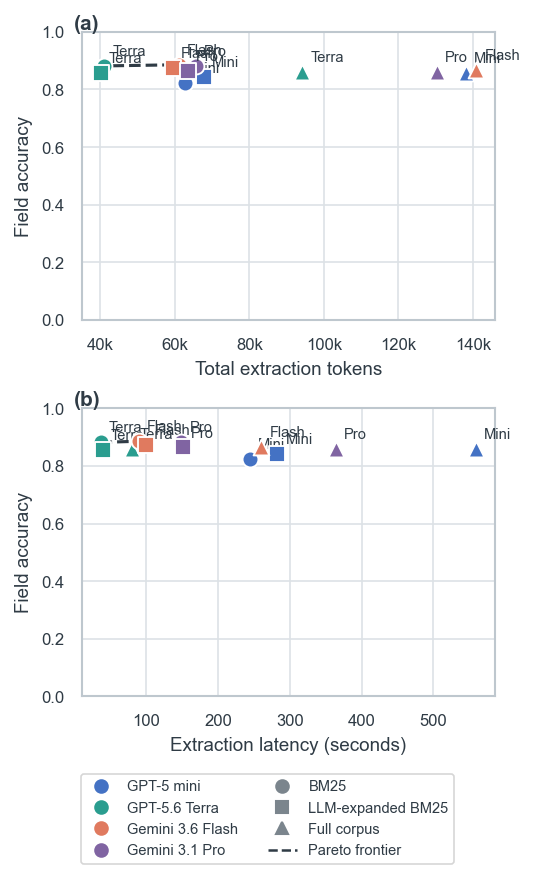

In [12]:
pareto_full, _ = plot_quality_cost(ylim=PARETO_FULL_YLIM)
pareto_full.savefig(FIGURE_DIR / "rq2-quality-cost-pareto-full-scale.pdf")
# pareto_full.savefig(FIGURE_DIR / "rq2-quality-cost-pareto-full-scale.png", dpi=DPI)
plt.show()

## Additional operational measurements

The following diagnostic table is not a primary quality result. It helps
explain cost and convergence by reporting average model calls, rejected
findings, unresolved fields, reconciliation conflicts, token direction, and
full profile-build latency for each model-retrieval combination.

In [13]:
display(diagnostics.style.format({
    "model_calls": "{:.1f}", "rejected_count": "{:.1f}",
    "unresolved_count": "{:.1f}", "conflicts": "{:.1f}",
    "input_tokens": "{:,.0f}", "output_tokens": "{:,.0f}",
    "profile_latency_sec": "{:.1f}",
}))

# print(ieee_latex_table(
#     diagnostics,
#     caption="Operational diagnostics by model-retrieval combination.",
#     label="tab:rq2-diagnostics",
# ))

,Model,Retrieval,model_calls,rejected_count,unresolved_count,conflicts,input_tokens,output_tokens,profile_latency_sec
0,GPT-5 mini,BM25,5.0,19.8,47.1,2.9,"41,183","21,513",244.1
1,GPT-5 mini,LLM-expanded BM25,6.6,18.4,41.4,4.7,"42,832","24,910",282.8
2,GPT-5 mini,Full corpus,15.1,28.4,40.8,5.0,"92,003","46,097",559.4
3,GPT-5.6 Terra,BM25,4.4,5.0,38.7,4.7,"36,563","4,380",36.6
4,GPT-5.6 Terra,LLM-expanded BM25,5.7,13.0,43.3,4.7,"35,403","4,624",39.5
5,GPT-5.6 Terra,Full corpus,13.8,8.3,45.1,4.8,"85,628","8,505",79.9
6,Gemini 3.6 Flash,BM25,4.3,4.2,39.2,4.9,"39,874","21,195",90.0
7,Gemini 3.6 Flash,LLM-expanded BM25,5.3,8.2,41.4,4.8,"36,247","23,212",100.1
8,Gemini 3.6 Flash,Full corpus,14.6,11.4,44.7,5.0,"83,088","57,713",260.8
9,Gemini 3.1 Pro,BM25,4.9,6.8,39.6,4.7,"44,866","20,787",149.3


## Data-driven observations

In [14]:
best_model = model_summary.loc[model_summary["field_accuracy"].idxmax()]
best_retrieval = retrieval_summary.loc[retrieval_summary["field_accuracy"].idxmax()]
full = retrieval_summary.loc[retrieval_summary["Retrieval"] == "Full corpus"].iloc[0]
bm25 = retrieval_summary.loc[retrieval_summary["Retrieval"] == "BM25"].iloc[0]
most_variable = retrieval_summary.loc[retrieval_summary["run_to_run_sd"].idxmax()]

print(f"Highest model-level field accuracy: {best_model['Model']} "
      f"({best_model['field_accuracy']:.3f}).")
print(f"Highest retrieval-level field accuracy: {best_retrieval['Retrieval']} "
      f"({best_retrieval['field_accuracy']:.3f}).")
print(f"Full corpus used {full['tokens'] / bm25['tokens']:.2f}× BM25 tokens and "
      f"{full['latency_sec'] / bm25['latency_sec']:.2f}× its extraction latency.")
print(f"Largest pooled repeat SD: {most_variable['Retrieval']} "
      f"({most_variable['run_to_run_sd']:.3f}).")
print(f"Mechanical citation integrity: {table_1['Citation Integrity'].min():.3f} "
      "at every site.")

Highest model-level field accuracy: Gemini 3.6 Flash (0.875).
Highest retrieval-level field accuracy: BM25 (0.868).
Full corpus used 2.19× BM25 tokens and 2.43× its extraction latency.
Largest pooled repeat SD: LLM-expanded BM25 (0.028).
Mechanical citation integrity: 1.000 at every site.


## Interpretation guardrails

1. Mechanical citation integrity establishes provenance consistency, not
   entailment; semantic citation validity still requires review.
2. The experiment holds measurement, pilot results, and corpus fixed. It
   evaluates extraction and construction, not discovery variance.
3. Field accuracy differs by site knowability and ground-truth composition;
   model and retrieval tables therefore use balanced macro-averages.
4. The Pareto frontier describes only these observed configurations and API
   conditions; it is not a universal ranking of the model families.